## Викачати та підготувати дані
1. Завантажити датасет за допомогою функції fetch_openml.
2. Вивести форму матриці X і кількість унікальних міток у y.
3. Для попереднього огляду візуалізувати кілька прикладів зображень (наприклад, 10 випадкових цифр) у вигляді 28×28 пікселів.
## Реалізувати метод головних компонент (PCA)
1. Реалізувати PCA із кількістю компонент n_components=3.
2. Отримати матрицю проєкцій (X_pca) розміром (70000 × 3);
3. Вивести відсоток поясненої дисперсії для кожної компоненти (explained_variance_ratio_).
## Візуалізувати дані у просторі перших трьох компонент
1. Побудувати 3D-графік (PC1, PC2, PC3) для кращого розуміння структури даних (використати matplotlib.axes3d або plotly). Точки зафарбувати відповідно до класу цифри.
2. Проаналізувати, чи видно кластери для різних цифр, наскільки добре PCA відділяє класи у тривимірному просторі.
## Реконструкція зображень після зменшення розмірності
1. Використати метод inverse_transform() з PCA для відновлення даних із простору трьох компонент у оригінальний простір.
2. Вивести кілька прикладів (наприклад, 10 випадкових цифр):
оригінальне зображення;
реконструйоване після PCA з трьома компонентами.
## Проаналізувати залежність між помилкою реконструкції та кількістю компонент
1. Визначити помилку реконструкції (Mean Squared Error, MSE) як середнє квадратів різниці між початковими та реконструйованими значеннями пікселів.
2. Обчислити MSE(k) та відсоток поясненої дисперсії для різної кількості компонент k і побудувати відповідні графіки.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

print("Форма матриці X:", X.shape)
print("Унікальні мітки:", np.unique(y))
print("Кількість унікальних міток:", len(np.unique(y)))

Форма матриці X: (70000, 784)
Унікальні мітки: [0 1 2 3 4 5 6 7 8 9]
Кількість унікальних міток: 10


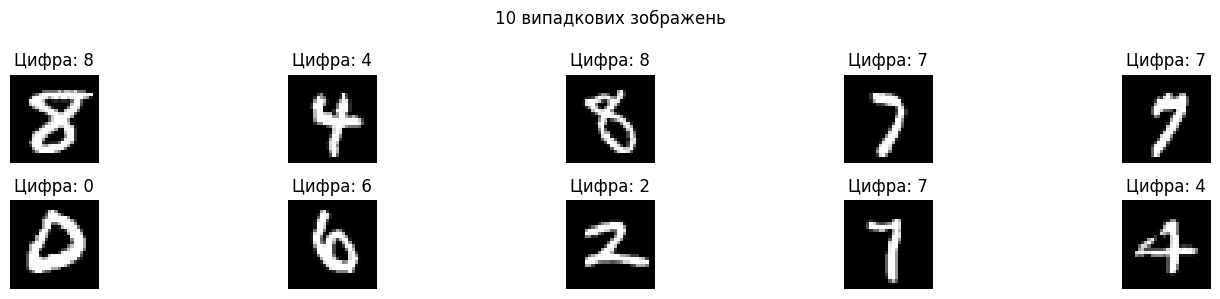

In [3]:
np.random.seed(42)
indices = np.random.choice(X.shape[0], 10, replace=False)

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Цифра: {y[idx]}")
    plt.axis('off')

plt.suptitle("10 випадкових зображень")
plt.tight_layout()
plt.show()

In [4]:
pca_3 = PCA(n_components=3)
X_pca = pca_3.fit_transform(X)

print("Форма матриці проєкцій X_pca:", X_pca.shape)
print("\nПояснена дисперсія для кожного компонента:")
for i, ratio in enumerate(pca_3.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio * 100:.4f}%")

print(f"\nСумарна пояснена дисперсія: {np.sum(pca_3.explained_variance_ratio_) * 100:.4f}%")

Форма матриці проєкцій X_pca: (70000, 3)

Пояснена дисперсія для кожного компонента:
PC1: 9.7461%
PC2: 7.1554%
PC3: 6.1495%

Сумарна пояснена дисперсія: 23.0511%


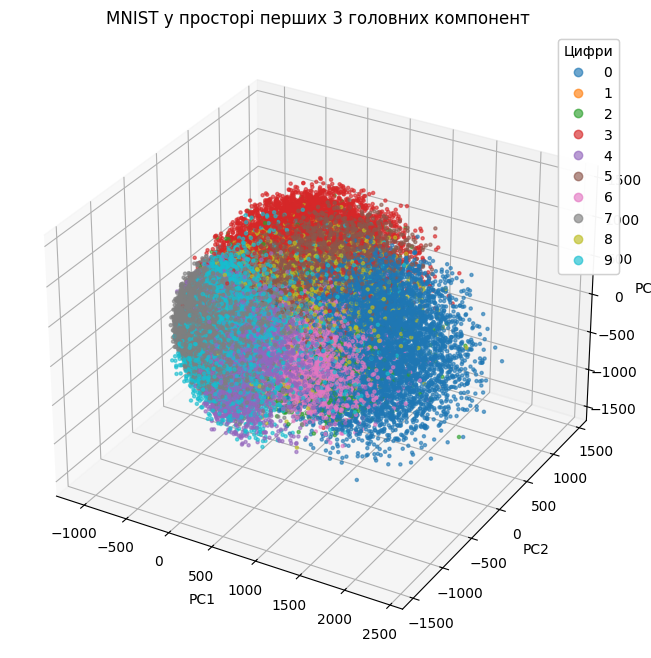

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y,
    cmap='tab10',
    s=5,
    alpha=0.6)

ax.set_title("MNIST у просторі перших 3 головних компонент")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

legend = ax.legend(*scatter.legend_elements(), title="Цифри")
ax.add_artist(legend)

plt.show()

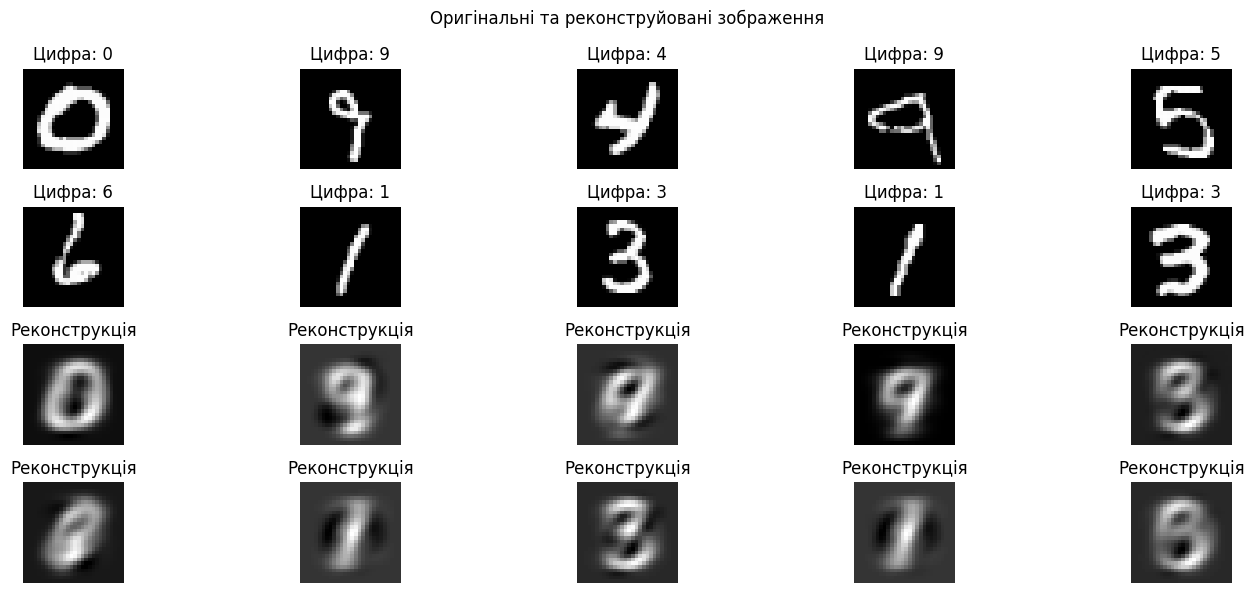

In [6]:
X_reconstructed_3 = pca_3.inverse_transform(X_pca)
np.random.seed(123)
recon_indices = np.random.choice(X.shape[0], 10, replace=False)
plt.figure(figsize=(15, 6))

for i, idx in enumerate(recon_indices):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Цифра: {y[idx]}")
    plt.axis('off')
    
    plt.subplot(4, 5, i + 11)
    plt.imshow(X_reconstructed_3[idx].reshape(28, 28), cmap='gray')
    plt.title("Реконструкція")
    plt.axis('off')

plt.suptitle("Оригінальні та реконструйовані зображення")
plt.tight_layout()
plt.show()

MSE реконструкції для 3 компонент: 3366.4897


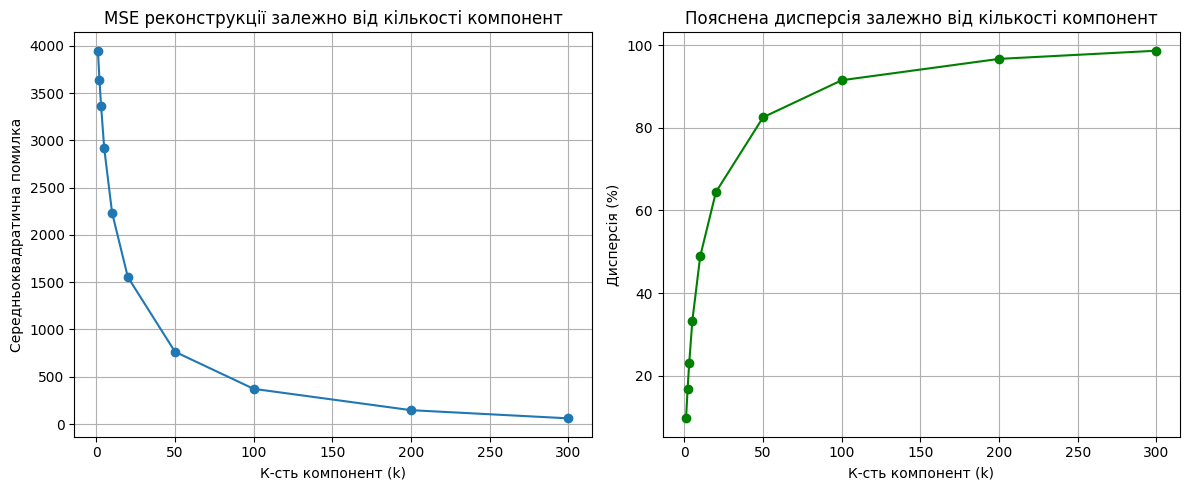

In [7]:
mse_3 = mean_squared_error(X, X_reconstructed_3)
print(f"MSE реконструкції для 3 компонент: {mse_3:.4f}")
components_list = [1, 2, 3, 5, 10, 20, 50, 100, 200, 300]
mse_list = []
explained_var_list = []

for k in components_list:    
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X)
    X_reconstructed_k = pca_k.inverse_transform(X_pca_k)
    
    mse = mean_squared_error(X, X_reconstructed_k)
    mse_list.append(mse)
    
    explained_var = np.sum(pca_k.explained_variance_ratio_)*100
    explained_var_list.append(explained_var)

plt.figure(figsize=(12, 5))
# Графік MSE
plt.subplot(1, 2, 1)
plt.plot(components_list, mse_list, marker='o')
plt.title("MSE реконструкції залежно від кількості компонент")
plt.xlabel("К-сть компонент (k)")
plt.ylabel("Середньоквадратична помилка")
plt.grid(True)

#Графік дисперсії
plt.subplot(1, 2, 2)
plt.plot(components_list, explained_var_list, marker='o', color='green')
plt.title("Пояснена дисперсія залежно від кількості компонент")
plt.xlabel("К-сть компонент (k)")
plt.ylabel("Дисперсія (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

## Висновок
У ході роботи було завантажено та досліджено датасет MNIST, а також застосовано метод головних компонент для зменшення розмірності даних. Було побудовано 3D-візуалізацію у просторі перших трьох компонент. Також виконано реконструкцію зображень і оцінено її якість за допомогою MSE: 3366,4897. Згідно з результатами, зі збільшенням кількості компонент точність відновлення зростає. На графіку поясненої дисперсії можна бачити, що 50 компонент зберігають достатньо багато інформації, така кількість була б оптимальним вибором.